# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

<StringArray>
['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri']
Length: 7, dtype: str

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

## Further exploratory data analysis

The starter cells above confirm we have **50,000 rows, 14 columns, and no missing values**. Before building any features, let's look at the target variable and the shape of the other columns in more depth — this is what will drive our feature engineering and modelling choices below.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print(df["booking_complete"].value_counts())
print()
print((df["booking_complete"].value_counts(normalize=True) * 100).round(2).astype(str) + "%")

booking_complete
0    42522
1     7478
Name: count, dtype: int64

booking_complete
0    85.04%
1    14.96%
Name: proportion, dtype: str


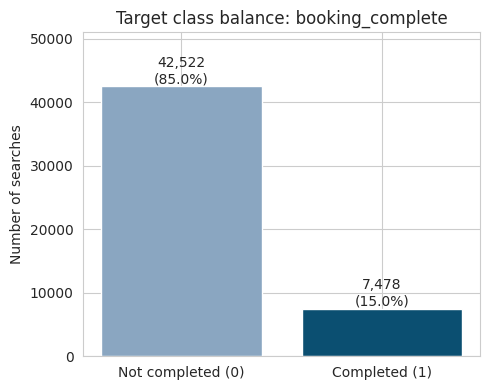

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["booking_complete"].value_counts().sort_index()
bars = ax.bar(["Not completed (0)", "Completed (1)"], counts.values, color=["#8AA6C1", "#0B4F71"])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 500, f"{v:,}\n({v/len(df):.1%})", ha="center", fontsize=10)
ax.set_ylabel("Number of searches")
ax.set_title("Target class balance: booking_complete")
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

**Only 14.96% of searches end in a completed booking.** This is a meaningfully imbalanced target — a model that always predicts "no booking" would already be ~85% accurate while being useless. This means:
- Raw **accuracy is a poor headline metric** for this problem — we'll lean on ROC-AUC, average precision (PR-AUC), and recall/precision on the "booking" class instead.
- We should use **stratified splits** for train/test and cross-validation so each fold keeps the same ~15% booking rate.
- It's worth trying **class-weighting** in the model so it isn't dominated by the majority class.

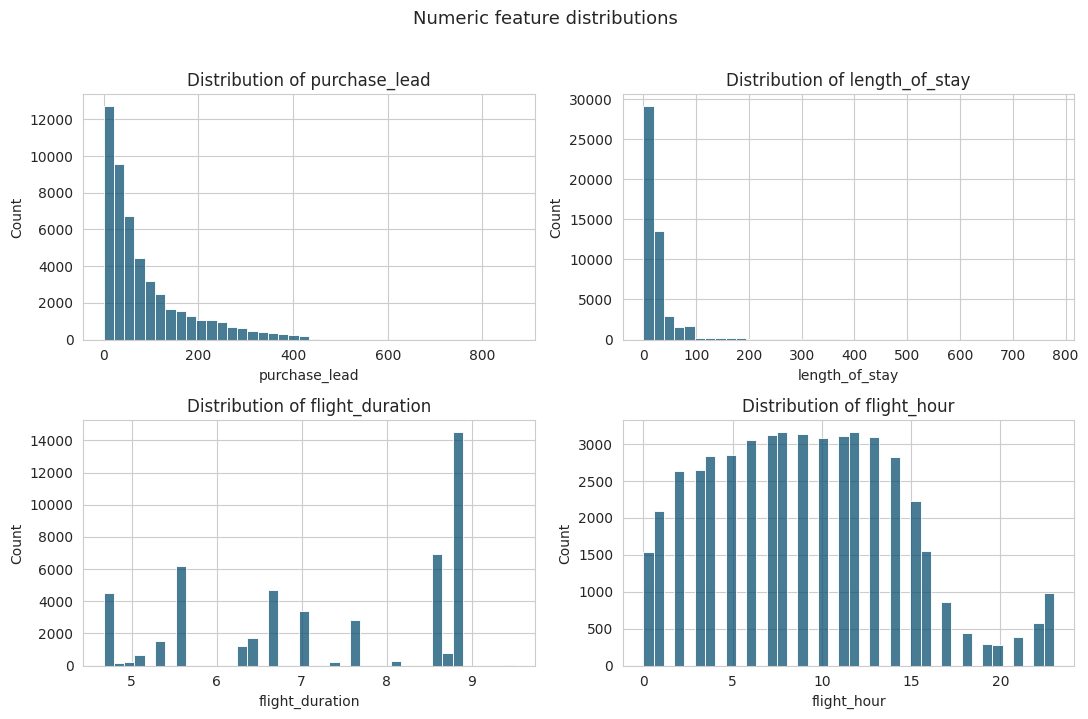

Skewness:
purchase_lead      1.65
length_of_stay     5.27
flight_duration   -0.36
flight_hour        0.40
dtype: float64


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plot_cols = ["purchase_lead", "length_of_stay", "flight_duration", "flight_hour"]
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#0B4F71")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
fig.suptitle("Numeric feature distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("Skewness:")
print(df[plot_cols].skew().round(2))

`purchase_lead` and especially `length_of_stay` are strongly **right-skewed** with a handful of extreme values (a few bookings are searched for stays of 700+ days). Skew and outliers are not a problem for a tree-based model like Random Forest — trees split on ranked thresholds rather than raw distances, so no scaling or log-transform is required before modelling. We'll simply carry these columns through as-is.

In [11]:
print("Exact duplicate rows:", df.duplicated().sum(), f"({df.duplicated().mean():.2%} of the data)")

# Check whether duplicate feature-rows always share the same outcome
dupe_groups = df[df.duplicated(keep=False)]
print("Rows involved in some duplicate group:", len(dupe_groups))

Exact duplicate rows: 719 (1.44% of the data)
Rows involved in some duplicate group: 1265


About 1.4% of rows are exact duplicates. With only a handful of numeric/categorical columns (and no customer ID), it's entirely expected that unrelated customers occasionally share the exact same combination of trip details by chance — these are **not necessarily data errors**, so we won't drop them. One practical implication: since identical feature combinations can have different outcomes for different real customers, there's a natural ceiling on how accurately *any* model can separate the classes using these features alone — worth keeping in mind when we look at performance metrics later.

In [12]:
print("=== Booking completion rate by sales channel ===")
print(df.groupby("sales_channel")["booking_complete"].mean().round(3))
print()
print("=== Booking completion rate by trip type ===")
print(df.groupby("trip_type")["booking_complete"].agg(["mean", "count"]).round(3))
print()
print("=== Booking completion rate: weekday vs weekend flights ===")
is_weekend = df["flight_day"].isin(["Sat", "Sun"])
print(df.groupby(is_weekend)["booking_complete"].mean().round(3))

=== Booking completion rate by sales channel ===
sales_channel
Internet    0.155
Mobile      0.108
Name: booking_complete, dtype: float64

=== Booking completion rate by trip type ===
             mean  count
trip_type               
CircleTrip  0.043    116
OneWay      0.052    387
RoundTrip   0.151  49497

=== Booking completion rate: weekday vs weekend flights ===
flight_day
False    0.15
Name: booking_complete, dtype: float64


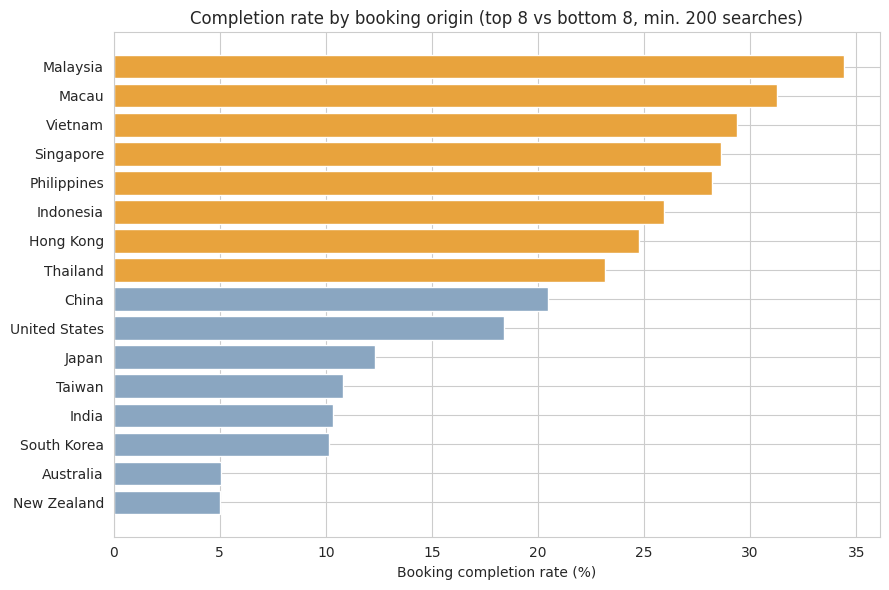

                    mean  count
booking_origin                 
Malaysia        0.344020   7174
Macau           0.312500    304
Vietnam         0.293814    388


...
                    mean  count
booking_origin                 
South Korea     0.101338   4559
Australia       0.050358  17872
New Zealand     0.050279   1074


In [13]:
origin_stats = df.groupby("booking_origin")["booking_complete"].agg(["mean", "count"])
origin_stats = origin_stats[origin_stats["count"] >= 200].sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top_bottom = pd.concat([origin_stats.head(8), origin_stats.tail(8)])
colors = ["#E8A33D" if c in origin_stats.head(8).index else "#8AA6C1" for c in top_bottom.index]
ax.barh(top_bottom.index[::-1], top_bottom["mean"].values[::-1] * 100, color=colors[::-1])
ax.set_xlabel("Booking completion rate (%)")
ax.set_title("Completion rate by booking origin (top 8 vs bottom 8, min. 200 searches)")
plt.tight_layout()
plt.show()

print(origin_stats.head(3))
print("...")
print(origin_stats.tail(3))

This is the single most important pattern in the dataset. Completion rate by country ranges from **~5% (Australia, New Zealand) to ~34% (Malaysia)** — a nearly 7x spread. Notably, **Australia is both the single largest source of searches (17,872, ~36% of the whole dataset) and one of the worst-converting markets.** This single categorical variable — *which country the customer is booking from* — looks set to be a dominant predictor, and it's a genuinely actionable business finding independent of any model: it's worth understanding what's different about the Australian customer journey. We'll confirm this quantitatively with feature importance later on.

## Feature engineering

Based on the EDA above, we'll create a small set of engineered features on top of the raw columns:

| New feature | Rationale |
|---|---|
| `flight_day_numeric` | Ordinal encoding of weekday (Mon=1 ... Sun=7), as set up in the starter cells above |
| `is_weekend_flight` | Explicit weekday/weekend flag — lets the model isolate this pattern in a single split rather than needing several |
| `route_origin_airport`, `route_destination_airport` | `route` alone has 799 unique values, which is too sparse to encode directly. Splitting it into its origin (85 unique airports) and destination (64 unique airports) halves lets the model learn from airport-level patterns rather than only exact-route patterns |
| `total_extras_requested` | Sum of `wants_extra_baggage` + `wants_preferred_seat` + `wants_in_flight_meals` (0–3) — a simple composite "engagement" score that's easy to explain to a non-technical audience |

High-cardinality categoricals (`route`, `route_origin_airport`, `route_destination_airport`, `booking_origin`) will be **frequency-encoded** rather than one-hot encoded — with 799 routes and 104 countries, one-hot encoding would create hundreds of sparse dummy columns, which both hurts Random Forest performance (each split only sees one rare category at a time) and — more importantly for this task — spreads the feature importance output across hundreds of tiny bars instead of one clean, interpretable bar per variable. Frequency encoding is done *inside* the modelling pipeline below (fit on training folds only) so there's no leakage into validation or test data.

In [14]:
def engineer_features(data):
    """Add engineered columns on top of the raw booking data. This is a pure,
    row-wise transformation (no target, no dataset-level statistics other than
    each row's own values), so it's safe to apply before the train/test split."""
    data = data.copy()

    day_mapping = {"Mon": 1, "Tue": 2, "Wed": 3, "Thu": 4, "Fri": 5, "Sat": 6, "Sun": 7}
    data["flight_day_numeric"] = data["flight_day"].map(day_mapping)
    data["is_weekend_flight"] = data["flight_day"].isin(["Sat", "Sun"]).astype(int)

    data["route_origin_airport"] = data["route"].str[:3]
    data["route_destination_airport"] = data["route"].str[3:]

    data["total_extras_requested"] = (
        data["wants_extra_baggage"] + data["wants_preferred_seat"] + data["wants_in_flight_meals"]
    )
    return data


df_model = engineer_features(df)
df_model[["flight_day", "flight_day_numeric", "is_weekend_flight",
          "route", "route_origin_airport", "route_destination_airport",
          "total_extras_requested"]].head()

,flight_day,flight_day_numeric,is_weekend_flight,route,route_origin_airport,route_destination_airport,total_extras_requested
0,6,NaN,0,AKLDEL,AKL,DEL,1
1,6,NaN,0,AKLDEL,AKL,DEL,0
2,3,NaN,0,AKLDEL,AKL,DEL,2
3,6,NaN,0,AKLDEL,AKL,DEL,1
4,3,NaN,0,AKLDEL,AKL,DEL,2


## Preparing the data for modelling

We split into training and held-out test sets **before** fitting any encoders, and use a **stratified** split so both sets keep the same ~15% booking rate as the full dataset.

In [15]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["booking_complete"])
y = df_model["booking_complete"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train booking rate: {y_train.mean():.2%} | Test booking rate: {y_test.mean():.2%}")

Train: 40,000 rows | Test: 10,000 rows
Train booking rate: 14.95% | Test booking rate: 14.96%


In [16]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Encodes each categorical column as the proportion of rows that share that
    category, learned only from the data passed to .fit(). Wrapped in a pipeline,
    this means frequencies are always learned from the training fold only — so
    there's no leakage from validation/test data during cross-validation."""

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = list(X.columns)
        self.freq_maps_ = {
            col: X[col].value_counts(normalize=True).to_dict() for col in self.columns_
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        out = np.column_stack([
            X[col].map(self.freq_maps_[col]).fillna(0.0).values for col in self.columns_
        ])
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{c}_freq" for c in self.columns_])


NUMERIC_FEATURES = [
    "num_passengers", "purchase_lead", "length_of_stay", "flight_hour",
    "wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals",
    "flight_duration", "flight_day_numeric", "is_weekend_flight", "total_extras_requested",
]
ONEHOT_FEATURES = ["sales_channel", "trip_type"]
FREQ_FEATURES = ["route", "route_origin_airport", "route_destination_airport", "booking_origin"]

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", NUMERIC_FEATURES),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), ONEHOT_FEATURES),
    ("freq", FrequencyEncoder(), FREQ_FEATURES),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Training a Random Forest model

We use a **Random Forest classifier**. It's a strong fit for this task for a few reasons:
- It captures **non-linear relationships and interactions** between variables without us having to specify them manually — useful here since none of the individual numeric features correlate strongly with the target on their own (all under 0.11 in magnitude), suggesting the real signal is in combinations of variables.
- It's **robust to skewed distributions, outliers, and unscaled features** — no preprocessing needed beyond encoding categoricals.
- Crucially for this task, it exposes **`feature_importances_`** directly — a clean, built-in measure of how much each variable contributed to the model's predictions, which is exactly what we need for the summary slide.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


def build_model(**rf_overrides):
    rf_params = dict(
        n_estimators=500, max_depth=12, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1,
    )
    rf_params.update(rf_overrides)
    return Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(**rf_params)),
    ])

**A quick note on the hyperparameters above.** Before settling on these, we compared a few configurations with 3-fold cross-validation on the training set: with vs. without `class_weight="balanced"`, and a few `max_depth` values. The unweighted model reached similar ROC-AUC but almost completely failed to identify the minority "booking" class (F1 ≈ 0.06, vs. ≈ 0.43 once balanced) — so `class_weight="balanced"` is essential here given the 85/15 imbalance. `max_depth=12` gave nearly identical ROC-AUC/PR-AUC to an unrestricted depth while being faster to train and easier to reason about, so we kept it. The comparison is reproduced below (using fewer trees and folds than the final evaluation, purely to keep this cell quick to run).

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

quick_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
configs = {
    "balanced, depth=12":   dict(n_estimators=150, max_depth=12, class_weight="balanced"),
    "unweighted, depth=12": dict(n_estimators=150, max_depth=12, class_weight=None),
    "balanced, depth=None": dict(n_estimators=150, max_depth=None, class_weight="balanced"),
}

rows = []
for name, kw in configs.items():
    m = build_model(**kw)
    s = cross_validate(m, X_train, y_train, cv=quick_cv,
                        scoring=["roc_auc", "average_precision", "f1"], n_jobs=1)
    rows.append({
        "config": name,
        "roc_auc": s["test_roc_auc"].mean(),
        "avg_precision": s["test_average_precision"].mean(),
        "f1": s["test_f1"].mean(),
    })

pd.DataFrame(rows).round(4)

,config,roc_auc,avg_precision,f1
0,"balanced, depth=12",0.7740,0.3592,0.4289
1,"unweighted, depth=12",0.7735,0.3604,0.0633
2,"balanced, depth=None",0.7791,0.3646,0.4134


## Cross-validation performance

With the hyperparameters settled, we run a proper **5-fold stratified cross-validation** on the training set to get a robust estimate of how the model generalises, using metrics suited to an imbalanced target: ROC-AUC, average precision (PR-AUC), precision, recall, F1, and accuracy (included for completeness, but de-emphasised for the reasons discussed above).

In [19]:
final_model = build_model()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    final_model, X_train, y_train, cv=cv,
    scoring=["roc_auc", "average_precision", "f1", "precision", "recall", "accuracy"],
    n_jobs=1,
)

cv_summary = pd.DataFrame({
    "mean": {k.replace("test_", ""): v.mean() for k, v in cv_results.items() if k.startswith("test_")},
    "std":  {k.replace("test_", ""): v.std()  for k, v in cv_results.items() if k.startswith("test_")},
}).round(4)
cv_summary

,mean,std
roc_auc,0.7778,0.0052
average_precision,0.3665,0.0090
f1,0.4309,0.0089
precision,0.3220,0.0073
recall,0.6515,0.0149
accuracy,0.7426,0.0056


Cross-validation confirms the model is **stable across folds** (low standard deviations) and clearly beats random guessing: ROC-AUC of ~0.78 (0.50 = random) and average precision of ~0.37 (vs. a ~0.15 baseline if we predicted at random given the 15% booking rate). Recall of ~0.65 means the model correctly flags roughly two-thirds of customers who go on to book, well above what the 15% base rate alone would suggest.

## Final model & held-out test evaluation

Finally, we fit the model on the **full training set** and evaluate once on the **held-out test set** (the 20% of data the model has never seen), which is what we report as the headline numbers.

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_proba)
test_avg_precision = average_precision_score(y_test, y_proba)

print(f"Held-out test ROC-AUC:            {test_roc_auc:.4f}")
print(f"Held-out test average precision:  {test_avg_precision:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No booking", "Booking"], digits=3))

Held-out test ROC-AUC:            0.7850
Held-out test average precision:  0.3821

              precision    recall  f1-score   support

  No booking      0.930     0.750     0.830      8504
     Booking      0.323     0.678     0.438      1496

    accuracy                          0.739     10000
   macro avg      0.626     0.714     0.634     10000
weighted avg      0.839     0.739     0.771     10000



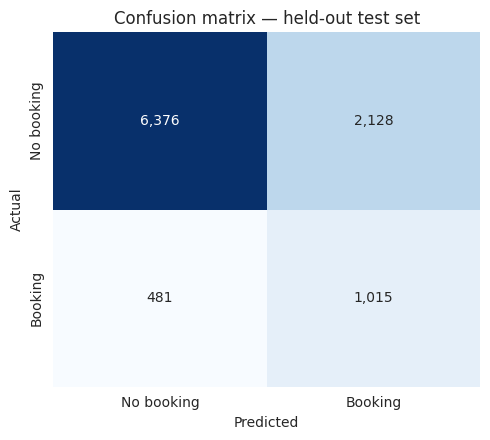

In [21]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["No booking", "Booking"], yticklabels=["No booking", "Booking"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — held-out test set")
plt.tight_layout()
plt.show()

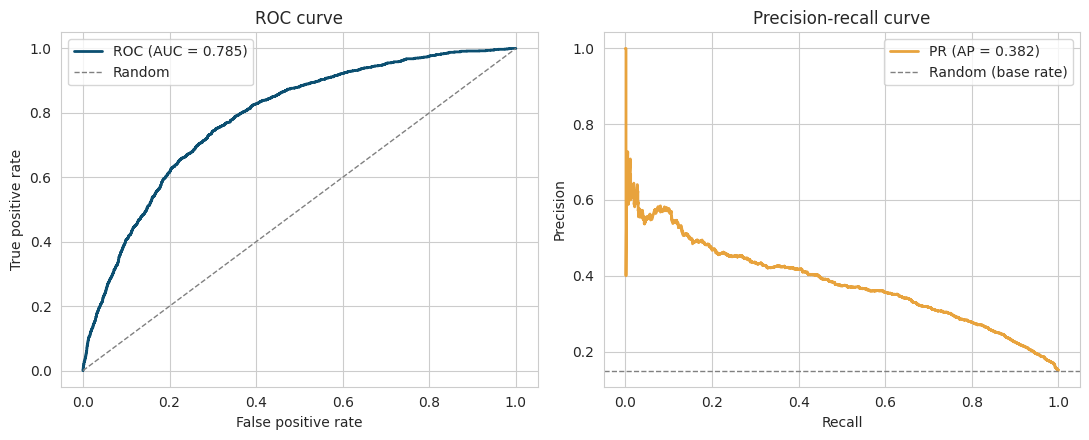

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color="#0B4F71", linewidth=2, label=f"ROC (AUC = {test_roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, label="Random")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, color="#E8A33D", linewidth=2, label=f"PR (AP = {test_avg_precision:.3f})")
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", linewidth=1, label="Random (base rate)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading these results:** with the default 0.5 probability threshold, the model catches **68% of customers who go on to book** (recall) but only **32% of the customers it flags as likely bookers actually book** (precision) — expected, given we chose `class_weight="balanced"` specifically to prioritise catching true bookers over avoiding false positives. This is a reasonable trade-off for a use case like targeting or prioritising follow-up, where missing a genuine booker is more costly than a wasted follow-up on a non-booker — but the threshold can be tuned higher if the business use case instead calls for higher-confidence (higher precision) flags at the cost of coverage. The gap between the ROC curve and the diagonal, and between the PR curve and the base-rate line, both confirm the model has real, non-trivial signal — it is comfortably better than random on this admittedly hard prediction problem (recall from the EDA that no single raw feature correlates with the target above 0.11 in magnitude).

## Feature importance — what drives booking completion?

This is the key output for the business: **which variables does the model rely on most** to predict whether a search turns into a completed booking?

In [23]:
feature_names = final_model.named_steps["prep"].get_feature_names_out()
clean_names = [n.split("__", 1)[1] if "__" in n else n for n in feature_names]
importances = final_model.named_steps["clf"].feature_importances_

fi = pd.DataFrame({"feature": clean_names, "importance": importances}).sort_values("importance", ascending=False)
fi["importance_pct"] = (fi["importance"] * 100).round(1)
fi.reset_index(drop=True)

,feature,importance,importance_pct
0,booking_origin_freq,0.288043,28.8
1,route_freq,0.102541,10.3
2,length_of_stay,0.100201,10.0
3,route_destination_airport_freq,0.098326,9.8
4,purchase_lead,0.087135,8.7
5,route_origin_airport_freq,0.085065,8.5
6,flight_duration,0.065710,6.6
7,flight_hour,0.058666,5.9
8,total_extras_requested,0.031518,3.2
9,wants_extra_baggage,0.020586,2.1


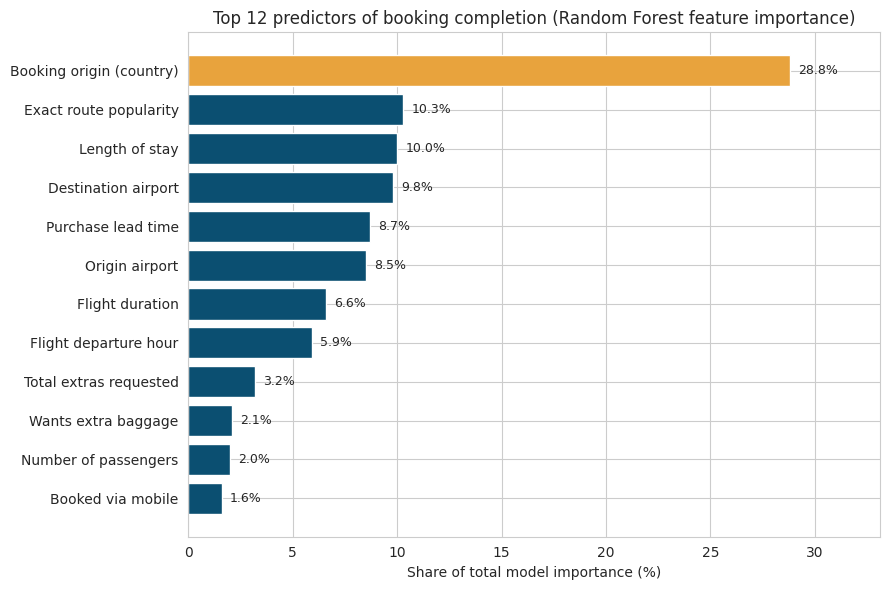

In [24]:
display_names = {
    "booking_origin_freq": "Booking origin (country)",
    "route_freq": "Exact route popularity",
    "length_of_stay": "Length of stay",
    "route_destination_airport_freq": "Destination airport",
    "purchase_lead": "Purchase lead time",
    "route_origin_airport_freq": "Origin airport",
    "flight_duration": "Flight duration",
    "flight_hour": "Flight departure hour",
    "flight_day_numeric": "Day of week",
    "total_extras_requested": "Total extras requested",
    "wants_extra_baggage": "Wants extra baggage",
    "num_passengers": "Number of passengers",
    "sales_channel_Mobile": "Booked via mobile",
    "wants_preferred_seat": "Wants preferred seat",
    "wants_in_flight_meals": "Wants in-flight meals",
    "is_weekend_flight": "Weekend flight",
    "trip_type_RoundTrip": "Trip type: round trip",
    "trip_type_OneWay": "Trip type: one way",
}
fi_plot = fi.head(12).copy()
fi_plot["label"] = fi_plot["feature"].map(display_names).fillna(fi_plot["feature"])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E8A33D"] + ["#0B4F71"] * (len(fi_plot) - 1)
ax.barh(fi_plot["label"][::-1], fi_plot["importance_pct"][::-1], color=colors[::-1])
for i, (v, y) in enumerate(zip(fi_plot["importance_pct"][::-1], range(len(fi_plot)))):
    ax.text(v + 0.4, y, f"{v}%", va="center", fontsize=9)
ax.set_xlabel("Share of total model importance (%)")
ax.set_title("Top 12 predictors of booking completion (Random Forest feature importance)")
ax.set_xlim(0, fi_plot["importance_pct"].max() * 1.15)
plt.tight_layout()
plt.show()

**Key findings:**

1. **Booking origin (country) is by far the strongest predictor**, at ~28% of total model importance — roughly 3x the next-highest feature. This lines up exactly with the EDA earlier: completion rate varies from ~5% (Australia, New Zealand) to ~34% (Malaysia). Note this feature is *frequency*-encoded (how common that country is in the data), which the model uses as an effective fingerprint for country identity — the takeaway is "which country" matters enormously, not that popularity itself drives conversion.
2. **Route and airport popularity together account for another ~27%** (exact route, origin airport, destination airport combined) — geography matters a lot, beyond just the country of origin.
3. **Trip logistics — length of stay and purchase lead time — matter more than the "extras"** customers request. Together they're worth almost as much as all three "wants" flags (baggage/seat/meal) and trip type combined.
4. **`trip_type` is essentially unused** (<0.2% importance) despite a large raw completion-rate gap between round trips (15%) and one-way/circle trips (~5%) seen in the EDA. This is because **99% of the dataset is round trips** — with so little variation, the model has almost no opportunity to split on it, and whatever signal it carries likely overlaps with other retained features (e.g. route, duration).

## Summary & recommendations

**Model:** Random Forest classifier (500 trees, max depth 12, class-balanced) predicting `booking_complete` from 18 engineered/encoded features.

**Performance (held-out test set, 10,000 searches):**
- ROC-AUC: **0.79** (0.50 = random)
- Average precision (PR-AUC): **0.38** (vs. ~0.15 baseline)
- Recall on bookings: **68%** | Precision on bookings: **32%**
- 5-fold cross-validation confirms these results are stable (std. dev. ≤ 0.015 on every metric)

**What drives a completed booking, in order:** (1) which country the customer is booking from — by a wide margin, (2) route and airport popularity, (3) trip logistics (length of stay, how far ahead they book), (4) flight timing (duration, hour, day). The specific "extras" a customer requests (baggage, seat, meal) and trip type matter comparatively little once the above are accounted for.

**Caveats:**
- The target is imbalanced (15% booking rate); the model is tuned to favour catching true bookers (recall) over precision — this threshold can be adjusted depending on how the predictions will be used downstream.
- ~1.4% of rows are exact duplicates with potentially different outcomes, implying some irreducible noise given only these features — a ceiling on achievable accuracy that no amount of further tuning will remove.
- This model explains *association*, not necessarily *causation* — e.g. the country effect may reflect the underlying booking platform, currency, competitor pricing, or customer intent captured only indirectly by "country," rather than country itself being the lever to pull.

**Suggested next steps:** dig into *why* markets like Australia convert so much worse despite high traffic (funnel/UX differences? competitor pricing? currency friction?); consider this model as a lead-scoring/prioritisation signal for marketing follow-up rather than a precise individual-level prediction; and revisit the classification threshold once there's a concrete downstream use case (e.g. cost of a missed booking vs. cost of an unnecessary follow-up).

*A one-slide executive summary of these findings is provided separately as a PowerPoint file.*